# E-commerce Sales Analysis with Pandas

This notebook complements the SQL analysis by using Pandas for:
- data loading
- lightweight validation
- cleaning and preparation
- dataset merging
- exploratory analysis
- simple visualizations


# 1. Imports and setup


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


# 2. Load datasets


In [2]:
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
category_translation = pd.read_csv("../data/raw/product_category_name_translation.csv")

# 3. Initial inspection

Store datasets in dictionary for easier bulk inspection.


Before transforming the data, this section checks the shape, schema, missing values, and duplicated rows for each source table.

This is an important quality gate: the goal is to understand whether each table can support reliable joins and whether any missing fields could affect revenue, customer, or category analysis.


In [3]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "category_translation": category_translation
}

for name, df in datasets.items():
    print(f"\n{'=' * 60}")
    print(f"{name.upper()}")
    print(f"{'=' * 60}")
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nInfo:")
    print(df.info())
    print("\nMissing values:")
    print(df.isnull().sum())
    print("\nDuplicate rows:", df.duplicated().sum())


CUSTOMERS
Shape: (99441, 5)

Columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None

Missing values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Duplicate rows: 0

ORDERS
Shape: (99441, 8)

Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'orde

# 4. Data cleaning and preparation


The cleaning step focuses on fields that directly affect analysis reliability: dates, category labels, and key uniqueness.

Date conversion is especially important because monthly trends, growth calculations, and seasonality analysis depend on valid timestamp fields.


## 4.1. Convert date columns

Convert imported text date columns into datetime format.

Invalid parsing will be converted to NaT for easier validation.


In [4]:
orders_date_columns = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 
                    'order_estimated_delivery_date']

for col in orders_date_columns:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')


orders[orders_date_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_purchase_timestamp       99441 non-null  datetime64[ns]
 1   order_approved_at              99281 non-null  datetime64[ns]
 2   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 3   order_delivered_customer_date  96476 non-null  datetime64[ns]
 4   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5)
memory usage: 3.8 MB


In [5]:
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'], errors='coerce')
order_items['shipping_limit_date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 112650 entries, 0 to 112649
Series name: shipping_limit_date
Non-Null Count   Dtype         
--------------   -----         
112650 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 880.2 KB


## 4.2. Standardize category names

Merge category translation table to standardize product category names in English.


In [6]:
products = products.merge(category_translation, how='left', on='product_category_name')

products['product_category_name_english'] = products['product_category_name_english'].fillna('Unknown')

In [7]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


## 4.3. Validate primary key uniqueness

Validate uniqueness of primary key-like columns.

Customer_unique_id duplicates are expected because one customer can place multiple orders


These checks validate whether the expected identifier columns behave like primary keys.

`customer_unique_id` is intentionally allowed to repeat because it represents the same real customer across multiple orders. For customer-level metrics, this field is more appropriate than `customer_id`, which is order-specific in this dataset.


In [8]:
print("Duplicated order_id: ", orders['order_id'].duplicated().sum())
print("Duplicated customer_id: ", customers['customer_id'].duplicated().sum())
print("Duplicated product_id: ", products['product_id'].duplicated().sum())
print("Repeated customer_unique_id values (expected for returning customers):", customers["customer_unique_id"].duplicated().sum())


Duplicated order_id:  0
Duplicated customer_id:  0
Duplicated product_id:  0
Repeated customer_unique_id values (expected for returning customers): 3345


# 5. Build analytical dataset

Combine all relevant tables into one analytical dataframe.

This creates the main dataset for business analysis


The analytical dataset combines orders, items, products and customers into one table at item level.

Because each order can contain multiple items, revenue calculations must be careful about aggregation level. Order-level metrics use distinct `order_id`, while item/category/product metrics use item-level rows.


In [9]:
sales_analysis_df = (orders.merge(order_items, on='order_id', how='inner')
                     .merge(products, on='product_id', how='left')
                     .merge(customers, on='customer_id', how='left'))

sales_analysis_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


# 6. Feature engineering

Create derived business metrics for analysis.


The original dataset columns are kept with their source names for traceability.

For business interpretation:

- `price` is treated as product revenue.
- `freight_value` is treated as freight revenue.
- `gross_item_value` is created as `price + freight_value` to represent the full item-level value paid by the customer.

Business-friendly names such as `product_revenue` and `freight_revenue` are used later in aggregated outputs, but the row-level dataset keeps the original raw column names.


In [10]:
# Gross item value represents the total item-level amount paid by the customer.
# price is treated as product revenue, and freight_value is treated as freight revenue.
sales_analysis_df['gross_item_value'] = sales_analysis_df['price'] + sales_analysis_df['freight_value']

# Extract year-month for time series analysis
sales_analysis_df['purchase_year_month'] = sales_analysis_df["order_purchase_timestamp"].dt.to_period("M").astype(str)

# Flag delivered orders
sales_analysis_df["is_delivered"] = sales_analysis_df["order_status"].eq("delivered")

sales_analysis_df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,gross_item_value,purchase_year_month,is_delivered
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,2017-10,True
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,2018-07,True
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,2018-08,True
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,2017-11,True
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,2018-02,True


# 7. Basic validation checks

Run basic data quality checks before analysis.


This section acts as a final quality checkpoint before business analysis.

The checks look for missing values in the merged dataset and confirm that price and freight values are not negative. Missing delivery dates are expected for non-delivered orders, which is one reason the revenue analysis is filtered to delivered orders only.


In [11]:
#Check for missing values and invalid price records.

print("Missing values in analytical dataset (sales_analysis_df):")
print(sales_analysis_df.isnull().sum().sort_values(ascending=False))

print("Rows with negative price:", (sales_analysis_df["price"] < 0).sum())
print("Rows with negative freight:", (sales_analysis_df["freight_value"] < 0).sum())
print("Rows with missing purchase timestamp:", sales_analysis_df["order_purchase_timestamp"].isna().sum())

Missing values in analytical dataset (sales_analysis_df):
order_delivered_customer_date    2454
product_name_lenght              1603
product_description_lenght       1603
product_category_name            1603
product_photos_qty               1603
order_delivered_carrier_date     1194
product_weight_g                   18
product_width_cm                   18
product_height_cm                  18
product_length_cm                  18
order_approved_at                  15
customer_state                      0
customer_city                       0
customer_unique_id                  0
product_category_name_english       0
gross_item_value                    0
purchase_year_month                 0
customer_zip_code_prefix            0
order_id                            0
customer_id                         0
freight_value                       0
price                               0
shipping_limit_date                 0
seller_id                           0
product_id                    

## 7.1. Data quality summary

This table translates validation checks into analyst decisions. It makes the QA logic explicit: each issue is tied to its business impact and how it is handled in the analysis.


In [12]:
missing_product_ids = order_items.loc[~order_items['product_id'].isin(products['product_id']), 'product_id'].nunique()
missing_category_translations = products.loc[
    products['product_category_name'].notna() & products['product_category_name_english'].eq('Unknown'),
    'product_category_name'
].nunique()
products_without_category = products['product_category_name'].isna().sum()

data_quality_summary = pd.DataFrame([
    {
        'check': 'Duplicate order_id',
        'result': int(orders['order_id'].duplicated().sum()),
        'impact': 'Order-level metrics can use order_id safely.',
        'decision': 'Use order_id as the order grain.'
    },
    {
        'check': 'Duplicate customer_id',
        'result': int(customers['customer_id'].duplicated().sum()),
        'impact': 'Customer table can join reliably to orders.',
        'decision': 'Use customer_id for joins.'
    },
    {
        'check': 'Repeated customer_unique_id',
        'result': int(customers['customer_unique_id'].duplicated().sum()),
        'impact': 'The same real customer can appear in multiple orders.',
        'decision': 'Use customer_unique_id for customer-level analysis.'
    },
    {
        'check': 'Duplicate product_id',
        'result': int(products['product_id'].duplicated().sum()),
        'impact': 'Product table can join reliably at product level.',
        'decision': 'Use product_id for product/category enrichment.'
    },
    {
        'check': 'Unmatched product_id in order_items',
        'result': int(missing_product_ids),
        'impact': 'Unmatched products would affect category analysis.',
        'decision': 'Use left joins and monitor Unknown categories.'
    },
    {
        'check': 'Product categories without English translation',
        'result': int(missing_category_translations),
        'impact': 'Some categories cannot be translated cleanly.',
        'decision': "Group missing translations as 'Unknown'."
    },
    {
        'check': 'Products without category',
        'result': int(products_without_category),
        'impact': 'Some product rows cannot be assigned to a category.',
        'decision': "Keep transactions and group as 'Unknown'."
    },
    {
        'check': 'Negative price rows',
        'result': int((sales_analysis_df['price'] < 0).sum()),
        'impact': 'Negative values would distort revenue.',
        'decision': 'No adjustment needed.'
    },
    {
        'check': 'Negative freight rows',
        'result': int((sales_analysis_df['freight_value'] < 0).sum()),
        'impact': 'Negative values would distort gross value.',
        'decision': 'No adjustment needed.'
    }
])

data_quality_summary


,check,result,impact,decision
0,Duplicate order_id,0,Order-level metrics can use order_id safely.,Use order_id as the order grain.
1,Duplicate customer_id,0,Customer table can join reliably to orders.,Use customer_id for joins.
2,Repeated customer_unique_id,3345,The same real customer can appear in multiple ...,Use customer_unique_id for customer-level anal...
3,Duplicate product_id,0,Product table can join reliably at product level.,Use product_id for product/category enrichment.
4,Unmatched product_id in order_items,0,Unmatched products would affect category analy...,Use left joins and monitor Unknown categories.
5,Product categories without English translation,2,Some categories cannot be translated cleanly.,Group missing translations as 'Unknown'.
6,Products without category,610,Some product rows cannot be assigned to a cate...,Keep transactions and group as 'Unknown'.
7,Negative price rows,0,Negative values would distort revenue.,No adjustment needed.
8,Negative freight rows,0,Negative values would distort gross value.,No adjustment needed.


# 8. Filter delivered orders for business analysis

Keep only delivered orders for revenue/business performance analysis.


Revenue and business performance metrics are calculated only from delivered orders.

This avoids counting canceled, unavailable, or incomplete orders as completed sales. The filter is a business rule, not just a technical cleaning step.


In [13]:
# Restrict analysis to completed/delivered orders only
# Excludes cancelled/incomplete transactions from revenue calculations

delivered_sales = sales_analysis_df[sales_analysis_df["order_status"] == "delivered"].copy()
delivered_sales.shape

(110197, 30)

## 8.1. SQL and Pandas reconciliation

These metrics are designed to match the SQL outputs. Reconciliation across tools helps confirm that filtering, joins, and metric definitions are consistent.


In [14]:
reconciliation_metrics = pd.DataFrame([
    {
        'metric': 'delivered_item_rows',
        'pandas_value': len(delivered_sales),
        'sql_definition': 'COUNT(*) after joining delivered orders to order_items'
    },
    {
        'metric': 'delivered_orders',
        'pandas_value': delivered_sales['order_id'].nunique(),
        'sql_definition': "COUNT(DISTINCT order_id) where order_status = 'delivered'"
    },
    {
        'metric': 'product_revenue',
        'pandas_value': round(delivered_sales['price'].sum(), 2),
        'sql_definition': 'SUM(price) for delivered orders'
    },
    {
        'metric': 'freight_revenue',
        'pandas_value': round(delivered_sales['freight_value'].sum(), 2),
        'sql_definition': 'SUM(freight_value) for delivered orders'
    },
    {
        'metric': 'gross_order_value',
        'pandas_value': round(delivered_sales['gross_item_value'].sum(), 2),
        'sql_definition': 'SUM(price + freight_value) for delivered orders'
    },
    {
        'metric': 'product_aov',
        'pandas_value': round(delivered_sales['price'].sum() / delivered_sales['order_id'].nunique(), 2),
        'sql_definition': 'SUM(price) / COUNT(DISTINCT order_id)'
    },
    {
        'metric': 'gross_aov',
        'pandas_value': round(delivered_sales['gross_item_value'].sum() / delivered_sales['order_id'].nunique(), 2),
        'sql_definition': 'SUM(price + freight_value) / COUNT(DISTINCT order_id)'
    }
])

reconciliation_metrics


,metric,pandas_value,sql_definition
0,delivered_item_rows,110197.00,COUNT(*) after joining delivered orders to ord...
1,delivered_orders,96478.00,COUNT(DISTINCT order_id) where order_status = ...
2,product_revenue,13221498.11,SUM(price) for delivered orders
3,freight_revenue,2198275.64,SUM(freight_value) for delivered orders
4,gross_order_value,15419773.75,SUM(price + freight_value) for delivered orders
5,product_aov,137.04,SUM(price) / COUNT(DISTINCT order_id)
6,gross_aov,159.83,SUM(price + freight_value) / COUNT(DISTINCT or...



# 9. Exploratory analysis


## 9.1. Monthly gross order value trend

Aggregate monthly revenue and calculate month-over-month growth.


Question: How does delivered gross order value evolve over time?

This analysis groups delivered sales by purchase month and calculates month-over-month growth in gross order value. Early or late months with very low volume should be interpreted carefully because they may represent partial dataset coverage rather than real business performance.


In [15]:
# Aggregate delivered revenue by month and calculate month-over-month growth.
# price is treated as product revenue; freight_value is tracked separately.

monthly_revenue = (
    delivered_sales
    .groupby('purchase_year_month', as_index=False)
    .agg(
        monthly_product_revenue=('price', 'sum'),
        monthly_freight_revenue=('freight_value', 'sum'),
        monthly_gross_order_value=('gross_item_value', 'sum')
    )
    .sort_values('purchase_year_month')
)

monthly_revenue['previous_month_gross_order_value'] = monthly_revenue['monthly_gross_order_value'].shift(1)

monthly_revenue['mom_growth_pct'] = (
    (monthly_revenue['monthly_gross_order_value'] - monthly_revenue['previous_month_gross_order_value'])
    / monthly_revenue['previous_month_gross_order_value']
) * 100
monthly_revenue['mom_growth_pct'] = monthly_revenue['mom_growth_pct'].round(2)

monthly_revenue


,purchase_year_month,monthly_product_revenue,monthly_freight_revenue,monthly_gross_order_value,previous_month_gross_order_value,mom_growth_pct
0,2016-09,134.97,8.49,143.46,NaN,NaN
1,2016-10,40325.11,6165.55,46490.66,143.46,32306.71
2,2016-12,10.90,8.72,19.62,46490.66,-99.96
3,2017-01,111798.36,15684.01,127482.37,19.62,649657.24
4,2017-02,234223.40,37015.92,271239.32,127482.37,112.77
5,2017-03,359198.85,55132.10,414330.95,271239.32,52.75
6,2017-04,340669.68,50142.72,390812.40,414330.95,-5.68
7,2017-05,489338.25,77513.15,566851.40,390812.40,45.04
8,2017-06,421923.37,68127.00,490050.37,566851.40,-13.55
9,2017-07,481604.52,84694.56,566299.08,490050.37,15.56


## 9.2. Top categories by gross order value

Calculate product revenue, freight revenue, gross order value, and gross value share by product category.


Question: Which categories generate the most delivered gross order value?

This view helps identify category concentration. If a small number of categories account for a large share of gross order value, the business may have strong category winners but also dependency risk.


In [16]:
category_revenue = (
    delivered_sales
    .groupby('product_category_name_english', as_index=False)
    .agg(
        product_revenue=('price', 'sum'),
        freight_revenue=('freight_value', 'sum'),
        gross_category_value=('gross_item_value', 'sum')
    )
    .sort_values(by='gross_category_value', ascending=False)
)

category_revenue['gross_revenue_contribution'] = (
    category_revenue['gross_category_value'] / category_revenue['gross_category_value'].sum()
) * 100


In [17]:
top_categories = category_revenue.head(10)

top_categories

,product_category_name_english,product_revenue,freight_revenue,gross_category_value,gross_revenue_contribution
44,health_beauty,1233131.72,178957.81,1412089.53,9.157654
71,watches_gifts,1166176.98,98156.14,1264333.12,8.199427
8,bed_bath_table,1023434.76,201774.50,1225209.26,7.945702
66,sports_leisure,954852.55,163404.36,1118256.91,7.252097
16,computers_accessories,888724.61,143999.16,1032723.77,6.697399
40,furniture_decor,711927.69,168402.23,880329.92,5.709098
50,housewares,615628.69,142763.56,758392.25,4.918310
21,cool_stuff,610204.10,81476.79,691680.89,4.485675
6,auto,578966.65,90488.10,669454.75,4.341534
43,garden_tools,470495.28,96650.40,567145.68,3.678042


## 9.3. Top customers by total spend

Aggregate spending and order count by customer.


Question: Which customers generate the most value?

Customer spend is aggregated by `customer_unique_id` to avoid treating the same real customer as multiple customers. This supports customer lifetime value analysis and highlights whether top spenders are repeat buyers or high-value one-time purchasers.


In [18]:
# Calculate customer lifetime spend and total distinct orders.
# Gross spend includes product value plus freight; product spend is kept separately.

customer_revenue = (
    delivered_sales
    .groupby('customer_unique_id', as_index=False)
    .agg(
        product_spent=('price', 'sum'),
        freight_spent=('freight_value', 'sum'),
        gross_spent=('gross_item_value', 'sum'),
        total_orders=('order_id', 'nunique')
    )
    .sort_values('gross_spent', ascending=False)
)

customer_revenue.head()


,customer_unique_id,product_spent,freight_spent,gross_spent,total_orders
3724,0a0a92112bd4c708ca5fde585afaa872,13440.0,224.08,13664.08,1
79636,da122df9eeddfedc1dc1f5349a1a690c,7388.0,183.63,7571.63,2
43168,763c8b1c9c68a0229c42c9fc6f662b93,7160.0,114.88,7274.88,1
80463,dc4802a71eae9be1dd28f5d788ceb526,6735.0,194.31,6929.31,1
25436,459bef486812aa25204be022145caa62,6729.0,193.21,6922.21,1


In [19]:
top_customers = customer_revenue.head(10)

top_customers

,customer_unique_id,product_spent,freight_spent,gross_spent,total_orders
3724,0a0a92112bd4c708ca5fde585afaa872,13440.0,224.08,13664.08,1
79636,da122df9eeddfedc1dc1f5349a1a690c,7388.0,183.63,7571.63,2
43168,763c8b1c9c68a0229c42c9fc6f662b93,7160.0,114.88,7274.88,1
80463,dc4802a71eae9be1dd28f5d788ceb526,6735.0,194.31,6929.31,1
25436,459bef486812aa25204be022145caa62,6729.0,193.21,6922.21,1
93081,ff4159b92c40ebe40454e3e6a7c35ed6,6499.0,227.66,6726.66,1
23411,4007669dec559734d6f53e029e360987,5934.6,146.94,6081.54,1
87148,eebb5dda148d3893cdaf5b5ca3040ccb,4690.0,74.34,4764.34,1
26640,48e1ac109decbb87765a3eade6854098,4590.0,91.78,4681.78,1
73127,c8460e4251689ba205045f3ea17884a1,4080.0,575.88,4655.88,4


## 9.4. Top products by quantity sold

Identify best-selling products by quantity sold.


Question: Which products sell the most units?

Quantity sold and product revenue are analyzed together because high-volume products are not always the highest-revenue products. This distinction is useful for inventory, pricing, and category strategy.


In [20]:
# Identify highest-selling products by quantity and gross value.

top_products = (
    delivered_sales
    .groupby('product_id', as_index=False)
    .agg(
        items_sold=('order_item_id', 'count'),
        product_revenue=('price', 'sum'),
        freight_revenue=('freight_value', 'sum'),
        gross_product_value=('gross_item_value', 'sum')
    )
    .sort_values('items_sold', ascending=False)
)

top_products = top_products.head(10)

top_products


,product_id,items_sold,product_revenue,freight_revenue,gross_product_value
21617,aca2eb7d00ea1a7b8ebd4e68314663af,520,37104.30,7093.45,44197.75
8429,422879e10f46682990de24d770e7f83d,484,26577.22,7624.04,34201.26
19290,99a4788cb24856965c36a24e339b6058,477,42049.66,7857.84,49907.50
7206,389d119b48cf3043d311335e499d9c6b,390,21336.79,7206.86,28543.65
6926,368c6c730842d78016ad823897a372db,388,21056.80,6927.60,27984.40
10589,53759a2ecddad2bb87a079a1f1519f73,373,20387.20,6881.03,27268.23
26436,d1c427060a0f73f6b889a5c7c61f2ac4,332,45620.56,13336.75,58957.31
10616,53b36df67ebb7c41585e8d54d6772e08,321,37454.63,2258.86,39713.49
2734,154e7e31ebfa092203795c972e5804a6,274,6173.26,3650.94,9824.20
7881,3dd2a17168ec895c781a9191c1e95ad7,272,40782.80,7093.26,47876.06



# 10. Visualizations


The visualizations summarize the main analytical findings for communication.

They are intentionally simple and business-oriented: trend, category concentration, customer spend distribution, top customers, and top products.


## 10.1 Monthly gross order value trend


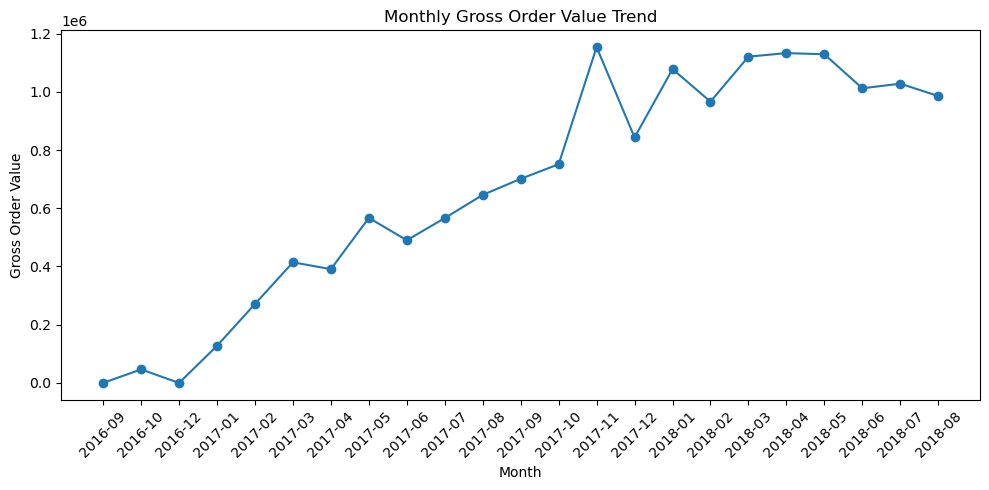

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(monthly_revenue['purchase_year_month'], monthly_revenue['monthly_gross_order_value'], marker='o')

plt.xticks(rotation=45)
plt.title('Monthly Gross Order Value Trend')
plt.xlabel('Month')
plt.ylabel('Gross Order Value')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'monthly_gross_order_value_trend.png', dpi=150, bbox_inches='tight')
plt.show()


## 10.2 Gross order value by category


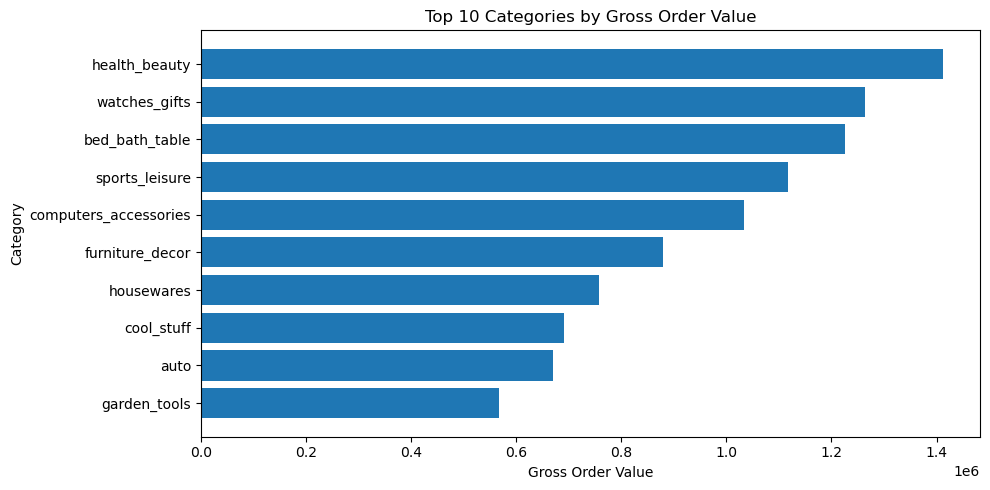

In [22]:
plt.figure(figsize=(10, 5))

plt.barh(top_categories['product_category_name_english'], top_categories['gross_category_value'])
plt.gca().invert_yaxis()

plt.title("Top 10 Categories by Gross Order Value")
plt.xlabel('Gross Order Value')
plt.ylabel('Category')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top_10_categories_by_gross_order_value.png', dpi=150, bbox_inches='tight')
plt.show()


## 10.3 Customer spent distribution 


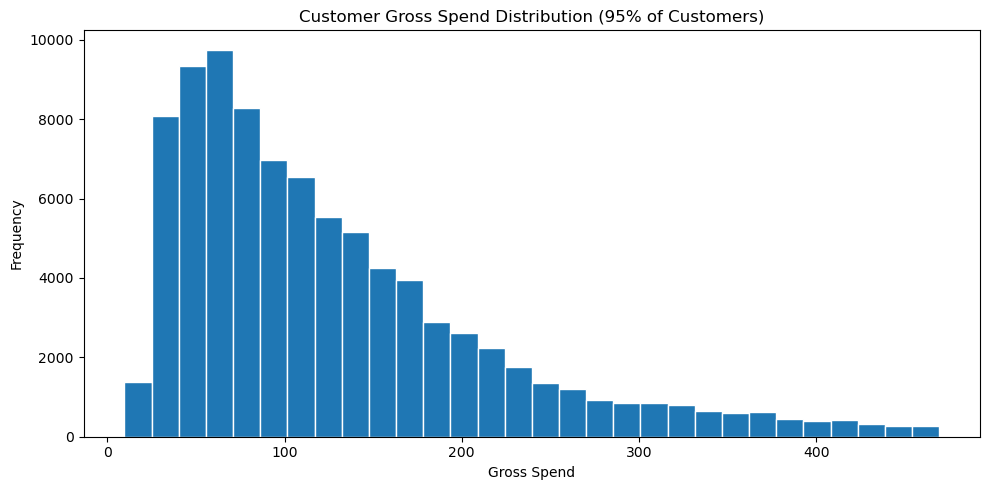

In [23]:
limit = customer_revenue['gross_spent'].quantile(0.95)

plt.figure(figsize=(10,5))

plt.hist(customer_revenue[customer_revenue['gross_spent'] <= limit]['gross_spent'], bins=30, edgecolor='white')

plt.title('Customer Gross Spend Distribution (95% of Customers)')
plt.xlabel('Gross Spend')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'customer_gross_spend_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 10.4 Top Customers by Spend


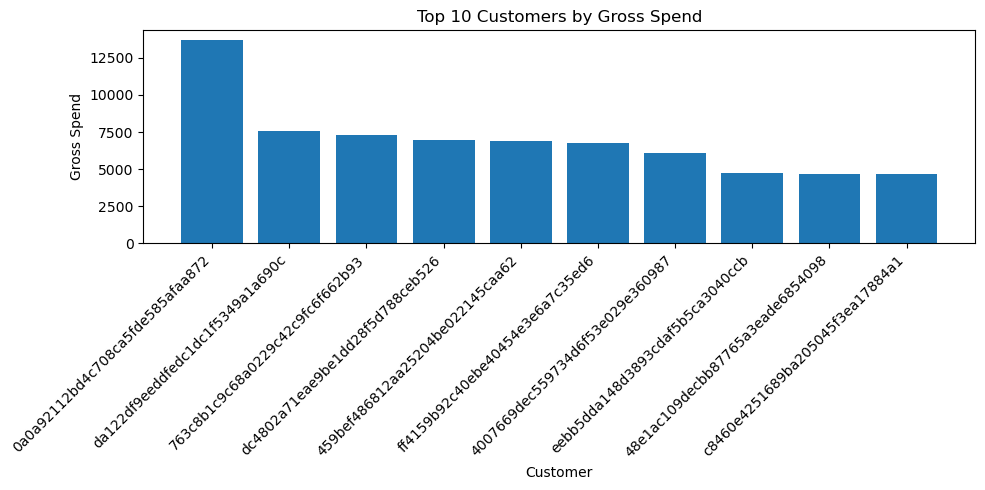

In [24]:
plt.figure(figsize=(10, 5))

plt.bar(top_customers["customer_unique_id"], top_customers["gross_spent"])

plt.xticks(rotation=45, ha="right")
plt.title('Top 10 Customers by Gross Spend')
plt.xlabel('Customer')
plt.ylabel('Gross Spend')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top_10_customers_by_gross_spend.png', dpi=150, bbox_inches='tight')
plt.show()


## 10.5 Top products by quantity sold


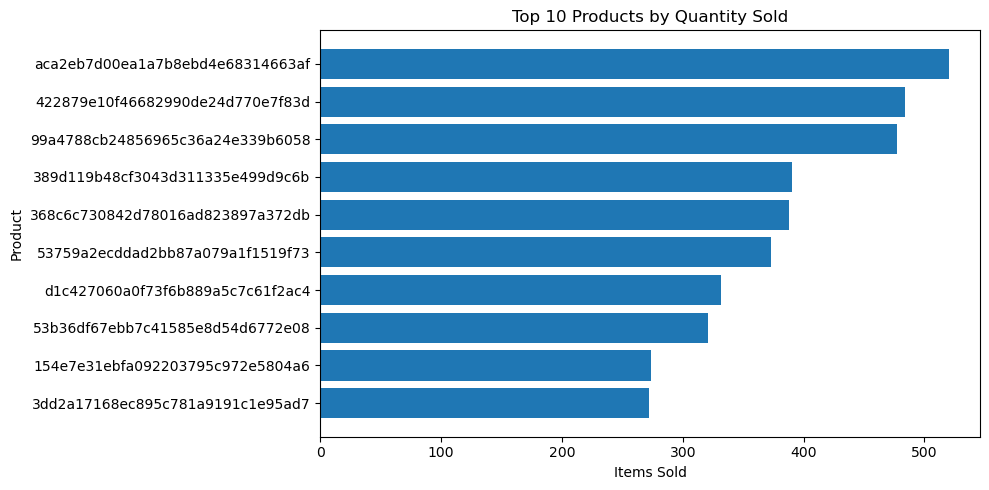

In [25]:
plt.figure(figsize=(10, 5))
plt.barh(top_products['product_id'], top_products['items_sold'])
plt.gca().invert_yaxis()
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Items Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top_10_products_by_quantity_sold.png', dpi=150, bbox_inches='tight')
plt.show()


# 11. Key insights


- Delivered orders generated `13,221,498.11` in product revenue and `2,198,275.64` in freight revenue, for a gross order value of `15,419,773.75`.
- Gross AOV is `159.83`, while product-only AOV is `137.04`; keeping freight separate avoids overstating product revenue.
- Revenue is concentrated by category: the top 5 categories account for `39.25%` of gross order value and the top 10 account for `62.38%`.
- Customer behavior is highly acquisition-heavy: `97.0%` of customers placed only one delivered order and `3.0%` placed more than one.
- Customer spend is right-skewed: most customers spend modest amounts, while a small number of customers represent high-value outliers.
- Product demand is concentrated among a limited number of SKUs, which can support inventory and assortment decisions.
- The analysis depends on clear business rules: delivered orders are counted as completed sales, product revenue excludes freight, and gross order value includes freight.
